# BONSAI vs extraction xfit for WCTE AmBe neutron captures

This notebook compares the compiled `WCSimBonsai` fitter with the grid
multilateration `xfit` used during extraction. Both algorithms receive the same
truth-guided hit clusters from `wcte_ambe_mc_digidata_0.root`, and both are
compared with `TTrueInfo.capture_{x,y,z}`.

The validation is deliberately **truth-guided**: for each known capture it
takes measured digi hits in a short window after `capture_t`, then gives each
algorithm only PMT identifiers, measured times, and (for BONSAI) charges. Truth
is used only afterward to measure the residual. This isolates vertex
reconstruction quality; it is not an end-to-end capture finder.

The extraction-grid path below calls the same
`extraction.observables.vertex.refit_vertex_by_multilateration_grid()` function
used to compute `xfit` during extraction. The BONSAI path calls the same
`extraction.bonsai.BonsaiVertexFitter` adapter used to compute `xbonsai` during
extraction. Both use defaults imported from `extraction.config`. The notebook
still differs from full extraction in how input clusters are obtained: here they
are selected around truth capture times, while extraction finds candidates after
prompt tagging and delayed Nn selection.


## How the two algorithms work

### BONSAI

For a trial vertex $\mathbf{x}$ and event time $t_0$, BONSAI evaluates
charge-binned timing-residual probabilities for
$r_i=t_i-t_0-|\mathbf{p}_i-\mathbf{x}|/v_\mathrm{water}$. The charge binning is
provided by the `like.bin` tune; the current WCTE tune is effectively a broad
single-bin timing model. BONSAI causally cleans the hits, creates seeds from
four-hit timing combinations, and refines surviving branches through staged
Clusfit and likelihood searches. Those searches are adaptive branch searches:
they test local neighborhoods, move to better branches, and shrink the search
radius until the configured stop radii are reached. The residual PDF comes from
`data/like.bin`, currently linked to the WCTE tune.

The notebook imports `extraction.bonsai.BonsaiVertexFitter`, the same adapter
used by extraction. `WCSimBonsai.Init(geometry)` is called once;
`BonsaiFit(...)` is called once per candidate. With the default WCTE/NuPRISM
geometry mode, BONSAI internally treats the vertical axis as `z`, so the adapter
converts the output back to WCTE `(x, y, z)`. It also applies the extraction
preprocessing: invalid hits are filtered and raw times are shifted to
`times - min(times) + 200 ns` immediately before the C++ fit.

For WCTE, the repository's detector-specific starting point is:

```bash
export BONSAIPARAM=$BONSAIDIR/data/fit_param_wcte.dat
```

### Extraction xfit grid multilateration

For every point on a coarse Cartesian grid centered on the
fixed prompt/source vertex, it subtracts geometrical TOF,
$t_i-|\mathbf{p}_i-\mathbf{x}|/(c/n)$, estimates $t_0$ with the median, and
scores the point with the RMS of the corrected times. It then scans a finer grid
around the best coarse point. The fine stage can discard seed hits with
`|corrected time - median| >= multilateration_dt_cut_ns`.

This notebook imports and calls the extraction implementation directly. That
means the grid bounds, steps, wall margin, water refractive index, earliest-hit
handling, seed multiplicity, and final Nn-window recomputation are the same as
extraction.

## Checks and validation sample

The one-capture check uses the same hit list for xfit and BONSAI.

The validation calls use `VALIDATION_INPUT_KWARGS["max_entries"]` as the ROOT
entry scan cap and `VALIDATION_MAX_FITS` as the fit cap. Passing clusters are
single-capture windows selected with `VALIDATION_INPUT_KWARGS["min_hits"]`,
`VALIDATION_INPUT_KWARGS["max_hits"]`, and
`VALIDATION_INPUT_KWARGS["time_window_ns"]`. These are intentionally clean
clusters, so the result characterizes vertex fitting rather than
candidate-selection efficiency.

The extraction xfit helper receives raw calibrated times plus the readout mPMT
slot and zero-based PMT-position IDs, maps them through the extraction geometry,
builds the extraction-style Nn seed/context, and then calls
`refit_vertex_by_multilateration_grid()`. Charges are not used for xfit. The
extraction implementation evaluates grid points in vectorized chunks; this
preserves the same grid and objective while changing only runtime and memory use.

## Interpreting the outputs

BONSAI:

- The notebook now uses `extraction.bonsai.BonsaiVertexFitter`, so the returned
  `vertex_cm = (x, y, z)` is already converted back to WCTE coordinates.
- The adapter receives raw calibrated times and applies the extraction time shift
  `times - min(times) + 200 ns` internally before calling `BonsaiFit`.
- `n_selected` is the number of hits surviving BONSAI's causal cleaning.
- `n_window` is the number in the final TOF-corrected `[-6, +12] ns` window.
- `time_goodness` and `fit_goodness` are the fitted-time and overall fit
  goodness values returned by the extraction adapter.
- The integer `n_fit` returned by `BonsaiFit` is a fit/search count, not the
  number of selected hits.
- Extraction stores only the spatial BONSAI vertex for candidate observables, so
  this notebook's BONSAI result tables leave `reco_time_ns` and `dt_ns` as NaN.

Extraction xfit grid multilateration:

- `(reco_x_cm, reco_y_cm, reco_z_cm)` is the same WCTE-coordinate `xfit` vertex
  produced by the extraction refit function for the supplied local context.
- The notebook first finds the extraction-style Nn seed using the configured
  `nn_window_ns` after source-vertex TOF correction, then builds the same
  `fit_context_ns` local context around that seed center.
- `Nn` is the seed-window multiplicity before the vertex refit. `Nn_refit` is
  recomputed at `xfit` from the best configured-width corrected-time window.
- `trms_ns` is the final refit-window corrected-time RMS, while `seed_trms_ns`
  is the original source-vertex seed-window RMS.
- `fpdist_cm` is `|xfit - prompt_vertex_cm|`; `fwall_cm` is the signed distance
  from `xfit` to the extraction wall proxy.
- The grid objective minimizes the fixed seed-hit timing RMS. It does not
  directly optimize truth residual or final-window multiplicity.

## Main tuning parameters to know

| Knob | What it controls | What to watch in WCTE captures |
|---|---|---|
| `data/like.bin` | Charge-binned PDF of hit-time residual `t - TOF - t0` | This is the core BONSAI likelihood model. It must match PMT timing, optical response, geometry, and digitization. The current link is `WCTE.bin`, which behaves effectively like a broad single charge bin. |
| PMT time resolution / coincidence time | Width allowed when deciding whether hits are compatible in BONSAI | Too small rejects real late/scattered hits; too large admits accidental hits and weakens timing constraints. |
| Pair distance/time fractions | BONSAI causal preselection of hit pairs | These alter `n_selected` and therefore both robustness and CPU cost. Tune before interpreting search-radius changes. |
| Maximum hits for all four-hit combinations | Whether every 4-hit BONSAI seed is tried | Larger values improve seeding for small clusters but scale combinatorially. WCTE uses 20 versus 12 in the generic file. |
| Initial/Clusfit/BONSAI grid constants | Spacing/density of BONSAI seed grids | Must be commensurate with the detector size. Generic 100-200 cm scales are far too coarse for a roughly 3 m detector. |
| Minimum wall distances | Which BONSAI seeds/fits are allowed near or outside the PMT envelope | Positive WCTE values suppress unphysical outside-detector solutions. Check edge-source performance before tightening. |
| Goodness time windows (10, 7, 5, 4 ns) | Timing widths during successive BONSAI Clusfit passes | Narrower late passes sharpen the vertex but can lose low-hit/noisy captures. |
| Search start/stop radii | Adaptive BONSAI branch-search radii, not Cartesian grid spacing | Smaller stop radii refine the search more and cost CPU. WCTE's coarse/fine stop radii are 10/6 cm; this is a search scale, not a direct precision measurement. |
| Skim differences/fractions | How aggressively poor BONSAI search branches are discarded | More aggressive skimming is faster but can remove the correct branch in sparse or contaminated clusters. |
| Cherenkov angles and angle weights | Directional constraint during Clusfit/BONSAI | WCTE capture tuning uses broad `90 deg` assumptions, appropriate for isotropic-ish cascades; SK-like `45 deg` assumptions bias this use case. |
| Number of Clusfit passes | Number of staged BONSAI refinements | More passes can improve difficult fits but add runtime. |

The analysis-side choices are just as important: cluster width, minimum hit
multiplicity, calibrated-vs-raw time, charge treatment, bad-channel masking, and
the exact `(slot, position) -> cable` mapping. For neutron captures, tune these
together with BONSAI rather than treating the fitter as an isolated black box.

## Extraction BONSAI parameters and usage

The notebook BONSAI call is intentionally thin:

```python
fit = bonsai_fitter.fit(
    cable_ids=candidate["cable_ids"],
    times_ns=candidate["times_raw_ns"],
    charges_pe=candidate["charges_pe"],
)
```

`bonsai_fitter` is an `extraction.bonsai.BonsaiVertexFitter` initialized with
`DEFAULT_BONSAI_DIR`, `DEFAULT_WCSIM_DIR`, `DEFAULT_BONSAI_PARAM`, and
`DEFAULT_BONSAI_GEOMETRY_ROOT` from `extraction.config`. It is the same adapter
created in `candidate_preselection.py` during extraction. The wrapper filters
invalid hits, shifts the selected raw times to `times - min(times) + 200 ns`,
passes cable IDs/times/charges to the C++ `BonsaiFit`, and returns the spatial
vertex in WCTE coordinates.

The full extraction script uses `bonsai_window_ns` to choose the broader
corrected-time hit neighborhood sent to BONSAI. This truth-guided notebook still
builds its input cluster around the known capture time, so identical BONSAI
outputs require identical selected hit arrays, not just the same ROOT event.

## Extraction xfit parameters and usage

The notebook xfit call mirrors the extraction call shape:

```python
xfit, nn_refit, best_context_loc, trmsp = refit_vertex_by_multilateration_grid(
    context_times_ns,
    context_pos_cm,
    prompt_vertex_cm,
    c_water_cm_per_ns,
    nn_window_ns,
    fit_hit_indices=seed_context_loc,
    fit_channel_keys=context_channel_keys,
    xyz_bounds_cm=DEFAULT_MULTILATERATION_XYZ_BOUNDS_CM,
    coarse_step_cm=DEFAULT_MULTILATERATION_COARSE_STEP_CM,
    fine_step_cm=DEFAULT_MULTILATERATION_FINE_STEP_CM,
    refine_halfwidth_cm=DEFAULT_MULTILATERATION_REFINE_HALFWIDTH_CM,
    dt_cut_ns=DEFAULT_MULTILATERATION_DT_CUT_NS,
    grid_chunk_size=DEFAULT_MULTILATERATION_GRID_CHUNK_SIZE,
    min_fit_hits=DEFAULT_MULTILATERATION_MIN_HITS,
    earliest_per_channel=DEFAULT_MULTILATERATION_EARLIEST_PER_CHANNEL,
    wall=extraction_wall,
    wall_margin_cm=DEFAULT_FIT_WALL_MARGIN_CM,
)
```

Current extraction defaults are imported by this notebook from
`extraction.config` and summarized in the setup cell as `CONFIG_SUMMARY`:

```text
prompt vertex = DEFAULT_PROMPT_VERTEX_CM
water refractive index = DEFAULT_WATER_REFRACTIVE_INDEX
Nn window = DEFAULT_NN_WINDOW_NS
Nn cut = DEFAULT_NN_CUT, meaning Nn > DEFAULT_NN_CUT before refit
fit context = DEFAULT_FIT_CONTEXT_NS around the prompt-vertex-corrected Nn seed center
fit wall margin = DEFAULT_FIT_WALL_MARGIN_CM
coarse grid half-width = DEFAULT_MULTILATERATION_XYZ_BOUNDS_CM around the prompt vertex
coarse step = DEFAULT_MULTILATERATION_COARSE_STEP_CM
fine grid half-width = DEFAULT_MULTILATERATION_REFINE_HALFWIDTH_CM around the best coarse point
fine step = DEFAULT_MULTILATERATION_FINE_STEP_CM
fine-stage dt cut = DEFAULT_MULTILATERATION_DT_CUT_NS
grid chunk size = DEFAULT_MULTILATERATION_GRID_CHUNK_SIZE
minimum seed hits after filtering = DEFAULT_MULTILATERATION_MIN_HITS
earliest hit per channel = DEFAULT_MULTILATERATION_EARLIEST_PER_CHANNEL
```

| Parameter | Role | Main trade-off / warning |
|---|---|---|
| `prompt_vertex_cm` | Fixed source/prompt vertex. It centers the coarse grid and defines the initial TOF correction and `fpdist`. | Moving it moves the search volume and changes every corrected time used to seed candidates. |
| `water_refractive_index` / `c_water_cm_per_ns` | Sets photon group speed used for all TOF subtraction. | Even small changes shift corrected times and can change the best grid point for tight clusters. |
| `nn_window_ns` | Width of the densest corrected-time window used for the initial Nn seed and final refit window. | Narrower windows are cleaner but can drop real scattered/late capture light. |
| `nn_cut` | Candidate must have `Nn > nn_cut`; with the default `DEFAULT_NN_CUT`, this means at least `DEFAULT_NN_CUT + 1` hits. | Raising it reduces accidentals but loses low-light captures. |
| `fit_context_ns` | Selects local hits around the seed center before refitting. | Too small removes useful constraints; too large lets unrelated delayed hits pull the vertex. |
| `fit_wall_margin_cm` | Minimum distance inside the cylindrical wall proxy for trial grid points. | Positive values suppress outside-detector fits; too strict can bias edge candidates. |
| `multilateration_xyz_bounds_cm` | Half-width of the coarse cubic grid around `prompt_vertex_cm`. | Larger searches catch farther solutions but scale cubically and may admit remote minima. |
| `multilateration_coarse_step_cm` | Coarse grid spacing. | Smaller is less likely to miss a basin but is much slower. |
| `multilateration_refine_halfwidth_cm` | Half-width of the fine grid around the best coarse point. | Must be wide enough to contain the local minimum after coarse quantization. |
| `multilateration_fine_step_cm` | Fine grid spacing and nominal coordinate granularity. | Smaller improves granularity but scales cubically. |
| `multilateration_dt_cut_ns` | Fine-stage cut on seed-hit residuals around the median corrected time. | Rejects outlier seed hits; if too tight, the fine stage can fall back to the uncut score. |
| `multilateration_grid_chunk_size` | Number of grid points vectorized at once. | Changes memory/runtime only, not the objective or result. |
| `multilateration_min_hits` | Minimum seed-hit constraints after finite filtering and earliest-per-channel reduction. | If fewer remain, extraction falls back to the prompt vertex for the local refit. |
| `multilateration_earliest_per_channel` | Keeps only the earliest seed hit for each `(slot, PMT position)` before scoring grid points. | Reduces repeated-pulse bias, but removes later hits from the fit constraints. |
| `geometry_file`, `pos_scale_to_cm`, `pmt_position_base` | Map readout `(slot, position)` to PMT coordinates. | Any mismatch here changes PMT positions and therefore the fitted vertex. |
| `wall_axis` / `wall_json` | Defines the wall proxy used to reject trial grid points. | The default is a finite cylinder built from the PMT geometry with vertical `y`. |
| `time_branch` | Chooses which PMT hit time branch enters extraction. | The notebook uses calibrated PMT times, matching extraction's default. |


## Benchmarks from this sample

Re-run the validation cells to refresh the benchmark table for the current
notebook state. The comparison writes files under `RESULTS_DIR`:

```text
extraction_xfit_neutron_capture_results.csv
bonsai_neutron_capture_results.csv
vertex_algorithm_comparison.csv
```

This remains a reconstruction-only baseline on clean, truth-timed clusters, not
the final neutron-tagging resolution. The selected hit clusters are passed to
BONSAI and extraction `xfit` so their vertex fits can be compared directly.

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-bonsai")

from pathlib import Path
import sys
from time import perf_counter

import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_DIR = Path("/scratch/saborido/WCTE-AmBe-nTagging")
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from extraction.bonsai import BonsaiVertexFitter
from extraction.config import (
    C_LIGHT_CM_PER_NS,
    DEFAULT_BONSAI_DIR,
    DEFAULT_BONSAI_GEOMETRY_ROOT,
    DEFAULT_BONSAI_PARAM,
    DEFAULT_BONSAI_WINDOW_NS,
    DEFAULT_GEOMETRY_FILE,
    DEFAULT_GEOMETRY_SCALE_TO_CM,
    DEFAULT_PMT_POSITION_BASE,
    DEFAULT_WALL_AXIS,
    DEFAULT_PROMPT_VERTEX_CM,
    DEFAULT_WATER_REFRACTIVE_INDEX,
    DEFAULT_WCSIM_DIR,
    DEFAULT_NN_WINDOW_NS,
    DEFAULT_NN_CUT,
    DEFAULT_FIT_CONTEXT_NS,
    DEFAULT_FIT_WALL_MARGIN_CM,
    DEFAULT_MULTILATERATION_XYZ_BOUNDS_CM,
    DEFAULT_MULTILATERATION_COARSE_STEP_CM,
    DEFAULT_MULTILATERATION_FINE_STEP_CM,
    DEFAULT_MULTILATERATION_REFINE_HALFWIDTH_CM,
    DEFAULT_MULTILATERATION_DT_CUT_NS,
    DEFAULT_MULTILATERATION_GRID_CHUNK_SIZE,
    DEFAULT_MULTILATERATION_MIN_HITS,
    DEFAULT_MULTILATERATION_EARLIEST_PER_CHANNEL,
)
from extraction.geometry import PmtGeometry, WallEstimator
from extraction.observables.vertex import (
    greedy_nn_candidates,
    refit_vertex_by_multilateration_grid,
)

# Use the same BONSAI and extraction defaults as candidate_preselection.py.
BONSAI_DIR = Path(DEFAULT_BONSAI_DIR)
WCSIM_DIR = Path(DEFAULT_WCSIM_DIR)
INPUT_ROOT = Path(
    "/scratch/saborido/WCTE-AmBe-DAQ-simulator/daq_windows/output/"
    "wcte_ambe_mc_digidata_0.root"
)
FIT_PARAM = Path(DEFAULT_BONSAI_PARAM)
GEOMETRY_ROOT = Path(DEFAULT_BONSAI_GEOMETRY_ROOT)
RESULTS_DIR = Path("/scratch/saborido/WCTE-AmBe-nTagging/vertex_fit_tests")

# One-capture cells use this entry; validation cells use VALIDATION_INPUT_KWARGS.
ONE_CAPTURE_ENTRY = 123
CAPTURE_TIME_WINDOW_NS = (0.0, 60.0)
VALIDATION_MAX_FITS = 10_000
VALIDATION_INPUT_KWARGS = {
    "max_entries": 20_000,
    "min_hits": 5,
    "max_hits": 100,
    "time_window_ns": CAPTURE_TIME_WINDOW_NS,
    "require_single_capture": True,
}

# Precompute the constants passed into the extraction xfit helper.
EXTRACTION_PROMPT_VERTEX_CM = np.asarray(DEFAULT_PROMPT_VERTEX_CM, dtype=float)
EXTRACTION_C_WATER_CM_PER_NS = C_LIGHT_CM_PER_NS / DEFAULT_WATER_REFRACTIVE_INDEX
EXTRACTION_XFIT_CONFIG = {
    "xyz_bounds_cm": DEFAULT_MULTILATERATION_XYZ_BOUNDS_CM,
    "coarse_step_cm": DEFAULT_MULTILATERATION_COARSE_STEP_CM,
    "fine_step_cm": DEFAULT_MULTILATERATION_FINE_STEP_CM,
    "refine_halfwidth_cm": DEFAULT_MULTILATERATION_REFINE_HALFWIDTH_CM,
    "dt_cut_ns": DEFAULT_MULTILATERATION_DT_CUT_NS,
    "grid_chunk_size": DEFAULT_MULTILATERATION_GRID_CHUNK_SIZE,
    "min_fit_hits": DEFAULT_MULTILATERATION_MIN_HITS,
    "earliest_per_channel": DEFAULT_MULTILATERATION_EARLIEST_PER_CHANNEL,
}
XFIT_RESULTS_CSV = RESULTS_DIR / "extraction_xfit_neutron_capture_results.csv"
BONSAI_RESULTS_CSV = RESULTS_DIR / "bonsai_neutron_capture_results.csv"
COMPARISON_RESULTS_CSV = RESULTS_DIR / "vertex_algorithm_comparison.csv"
geofile = Path(DEFAULT_GEOMETRY_FILE)

# Fail early if any external file expected by ROOT, BONSAI, or xfit is missing.
for required_path in [
    BONSAI_DIR / "data" / "like.bin",
    BONSAI_DIR / "libWCSimBonsai.so",
    WCSIM_DIR / "lib" / "libWCSimRoot.so",
    FIT_PARAM,
    GEOMETRY_ROOT,
    INPUT_ROOT,
    geofile,
]:
    assert required_path.exists(), required_path

input_file = ROOT.TFile.Open(str(INPUT_ROOT))
if not input_file or input_file.IsZombie():
    raise OSError(f"Could not open input ROOT file: {INPUT_ROOT}")
readout = input_file.Get("WCTEReadoutWindows")
truth_tree = input_file.Get("TTrueInfo")
if not readout or not truth_tree:
    raise KeyError("Expected WCTEReadoutWindows and TTrueInfo trees")
readout_entries = int(readout.GetEntries())

# xfit uses the text geofile; BONSAI separately uses GEOMETRY_ROOT.
EXTRACTION_GEOMETRY = PmtGeometry.from_geofile(
    geofile,
    scale_to_cm=DEFAULT_GEOMETRY_SCALE_TO_CM,
)
EXTRACTION_WALL = WallEstimator.from_geometry(
    EXTRACTION_GEOMETRY,
    axis=DEFAULT_WALL_AXIS,
)
slot_pos_to_cable = {
    (int(slot), int(pos)): int(tube)
    for tube, slot, pos in zip(
        EXTRACTION_GEOMETRY.tube_id,
        EXTRACTION_GEOMETRY.slot,
        EXTRACTION_GEOMETRY.pos0,
    )
}
slot_pos_to_xyz = {
    (int(slot), int(pos)): xyz.astype(float)
    for slot, pos, xyz in zip(
        EXTRACTION_GEOMETRY.slot,
        EXTRACTION_GEOMETRY.pos0,
        EXTRACTION_GEOMETRY.xyz_cm,
    )
}

print("BONSAIPARAM:", FIT_PARAM)
print("likelihood PDF:", (BONSAI_DIR / "data" / "like.bin").resolve())
print("BONSAI geometry ROOT:", GEOMETRY_ROOT)
print("WCSim dir:", WCSIM_DIR)
print("input:", INPUT_ROOT)
print("xfit geometry:", geofile)
print(f"Readout entries: {readout_entries:,}")
display(pd.Series({
    "bonsai_dir": str(BONSAI_DIR),
    "wcsim_dir": str(WCSIM_DIR),
    "bonsai_param": str(FIT_PARAM),
    "bonsai_geometry_root": str(GEOMETRY_ROOT),
    "bonsai_window_ns": DEFAULT_BONSAI_WINDOW_NS,
    "prompt_vertex_cm": tuple(EXTRACTION_PROMPT_VERTEX_CM),
    "water_refractive_index": DEFAULT_WATER_REFRACTIVE_INDEX,
    "nn_window_ns": DEFAULT_NN_WINDOW_NS,
    "nn_cut": DEFAULT_NN_CUT,
    "fit_context_ns": DEFAULT_FIT_CONTEXT_NS,
    "fit_wall_margin_cm": DEFAULT_FIT_WALL_MARGIN_CM,
    **EXTRACTION_XFIT_CONFIG,
}, name="value").to_frame())

# Sanity-check that the geofile mapping agrees with the truth hit positions.
errors = []
missing = 0
for entry in range(min(200, readout_entries)):
    readout.GetEntry(entry)
    truth_tree.GetEntry(entry)
    for hit in range(int(readout.nhit_pmt_calibrated_times)):
        key = (int(readout.hit_mpmt_slot_ids[hit]), int(readout.hit_pmt_position_ids[hit]))
        expected = slot_pos_to_xyz.get(key)
        if expected is None:
            missing += 1
            continue
        stored = np.array([truth_tree.x[hit], truth_tree.y[hit], truth_tree.z[hit]], dtype=float)
        errors.append(float(np.linalg.norm(stored - expected)))
display(pd.Series({
    "comparisons": len(errors),
    "missing_mappings": missing,
    "max_position_difference_cm": max(errors) if errors else np.nan,
}).to_frame("value"))


def capture_candidate(entry, capture_index=0, time_window_ns=CAPTURE_TIME_WINDOW_NS):
    """Return one truth-time-guided capture cluster from the ROOT trees.

    This is intentionally not the full extraction candidate finder. It selects
    hits in a short window around a known truth capture time so the notebook can
    compare vertex fitters on the same clean input cluster.
    """
    readout.GetEntry(entry)
    truth_tree.GetEntry(entry)

    n_capture = int(truth_tree.ncapture_t)
    if not 0 <= capture_index < n_capture:
        raise IndexError(f"capture_index={capture_index}, but entry {entry} has {n_capture} captures")

    # Truth is used only to define this diagnostic cluster and later residuals.
    capture_time = float(truth_tree.capture_t[capture_index])
    truth_xyz = np.array([
        truth_tree.capture_x[capture_index],
        truth_tree.capture_y[capture_index],
        truth_tree.capture_z[capture_index],
    ], dtype=float)
    low = capture_time + time_window_ns[0]
    high = capture_time + time_window_ns[1]

    indices = []
    cable_ids = []
    for hit in range(int(readout.nhit_pmt_calibrated_times)):
        time = float(readout.hit_pmt_calibrated_times[hit])
        if not low <= time <= high:
            continue

        # BONSAI wants cable IDs; xfit keeps the readout slot/PMT IDs.
        key = (int(readout.hit_mpmt_slot_ids[hit]), int(readout.hit_pmt_position_ids[hit]))
        cable = slot_pos_to_cable.get(key)
        if cable is None:
            continue
        indices.append(hit)
        cable_ids.append(cable)

    times_raw = np.array([readout.hit_pmt_calibrated_times[i] for i in indices], dtype=float)
    charges = np.array([readout.hit_pmt_charges[i] for i in indices], dtype=float)
    capture_flags = np.array([truth_tree.hit_from_capture[i] for i in indices], dtype=bool)

    return {
        "entry": int(entry),
        "event_number": int(readout.event_number),
        "capture_index": int(capture_index),
        "capture_time_ns": capture_time,
        "truth_xyz_cm": truth_xyz,
        "indices": np.asarray(indices, dtype=int),
        "cable_ids": np.asarray(cable_ids, dtype=int),
        "mpmt_ids": np.asarray([readout.hit_mpmt_slot_ids[i] for i in indices], dtype=int),
        "pmt_ids": np.asarray([readout.hit_pmt_position_ids[i] for i in indices], dtype=int),
        "times_raw_ns": times_raw,
        "charges_pe": charges,
        "capture_flags": capture_flags,
        "n_true_capture_hits": int(capture_flags.sum()),
        "capture_hit_fraction": float(capture_flags.mean()) if len(capture_flags) else np.nan,
    }


def validation_candidates(
    max_entries=20_000,
    min_hits=5,
    max_hits=100,
    time_window_ns=CAPTURE_TIME_WINDOW_NS,
    require_single_capture=True,
):
    """Yield truth-time-guided capture clusters that pass simple validation cuts."""
    entry_stop = readout_entries if max_entries is None else min(readout_entries, int(max_entries))
    for entry in range(entry_stop):
        readout.GetEntry(entry)
        truth_tree.GetEntry(entry)
        n_capture = int(truth_tree.ncapture_t)

        # Keep the default validation sample unambiguous: one truth capture per readout.
        if require_single_capture and n_capture != 1:
            continue

        for capture_index in range(n_capture):
            candidate = capture_candidate(entry, capture_index, time_window_ns=time_window_ns)
            n_input = len(candidate["cable_ids"])
            if min_hits <= n_input <= max_hits:
                yield candidate


def show_one_capture_check(label, truth_xyz, reco_xyz, metrics=None):
    """Display coordinate-by-coordinate residuals for one fitted capture."""
    truth_xyz = np.asarray(truth_xyz, dtype=float)
    reco_xyz = np.asarray(reco_xyz, dtype=float)
    display(pd.DataFrame({
        "coordinate": ["x", "y", "z"],
        "truth_cm": truth_xyz,
        "reco_cm": reco_xyz,
        "reco_minus_truth_cm": reco_xyz - truth_xyz,
    }))
    print(f"{label} 3D residual: {np.linalg.norm(reco_xyz - truth_xyz):.2f} cm")
    if metrics:
        display(pd.Series(metrics, name="value").to_frame())


def residual_summary(results):
    """Summarize 3D residuals while tolerating empty result tables."""
    if "residual_cm" not in results:
        r = pd.Series(dtype=float)
    else:
        r = results["residual_cm"].dropna()
    return pd.Series({
        "fits": len(r),
        "median_cm": r.median(),
        "mean_cm": r.mean(),
        "p68_cm": r.quantile(0.68),
        "p90_cm": r.quantile(0.90),
        "max_cm": r.max(),
    })


def show_validation_checks(frame, title):
    """Show summary tables and diagnostic plots for one algorithm's validation run."""
    display(residual_summary(frame).to_frame("value"))
    if frame.empty:
        print(f"{title}: no successful fits to plot")
        return

    dt_abs = frame["dt_ns"].abs().dropna() if "dt_ns" in frame else pd.Series(dtype=float)
    if len(dt_abs):
        print(f"median |time residual|: {dt_abs.median():.3f} ns")
        print(f"68% |time residual|: {dt_abs.quantile(0.68):.3f} ns")
    else:
        print("time residuals: unavailable for this result table")
    display(frame.head(10))

    fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
    scatter = None
    for ax, coord in zip(axes.flat[:3], "xyz"):
        t = frame[f"truth_{coord}_cm"]
        r = frame[f"reco_{coord}_cm"]
        lo = min(t.min(), r.min()) - 5
        hi = max(t.max(), r.max()) + 5
        scatter = ax.scatter(t, r, c=frame.residual_cm, cmap="viridis", s=24, alpha=0.8)
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set(xlabel=f"truth {coord} [cm]", ylabel=f"reco {coord} [cm]", xlim=(lo, hi), ylim=(lo, hi))
        ax.grid(alpha=0.2)

    if scatter is not None:
        # Anchor to the whole grid so the colorbar sits outside on the right.
        cbar = fig.colorbar(scatter, ax=axes.ravel().tolist(), location="right", shrink=0.82, pad=0.02)
        cbar.set_label("3D vertex residual [cm]")

    ax = axes.flat[3]
    bins = np.arange(0, 170, 5)
    counts, edges, _ = ax.hist(frame.residual_cm, bins=bins, histtype="stepfilled", alpha=0.75)
    if len(counts) and np.max(counts) > 0:
        # For continuous residuals, the mode is the center of the highest histogram bin.
        mode_bin = 0.5 * (edges[int(np.argmax(counts))] + edges[int(np.argmax(counts)) + 1])
        ax.axvline(mode_bin, color="C2", ls="-.", label=f"mode bin ({mode_bin:.1f} cm)")
    ax.axvline(frame.residual_cm.median(), color="C1", ls="--", label="median")
    #ax.axvline(frame.residual_cm.quantile(0.68), color="C3", ls=":", label="68% quantile")
    ax.set(xlabel="3D vertex residual [cm]", ylabel="captures")
    ax.legend()
    ax.grid(alpha=0.2)
    fig.suptitle(title)


def fit_extraction_bonsai_candidate(fitter, candidate):
    """Fit one candidate through the same BONSAI adapter used by extraction."""
    start = perf_counter()
    fit = fitter.fit(
        # BonsaiVertexFitter performs extraction's internal filtering and time shift.
        cable_ids=candidate["cable_ids"],
        times_ns=candidate["times_raw_ns"],
        charges_pe=candidate["charges_pe"],
    )
    runtime_ms = 1000.0 * (perf_counter() - start)
    if not fit.success:
        return {
            "success": False,
            "failure_reason": fit.failure_reason,
            "runtime_ms": runtime_ms,
        }

    truth_xyz = np.asarray(candidate["truth_xyz_cm"], dtype=float)
    reco_xyz = np.asarray(fit.vertex_cm, dtype=float)
    delta = reco_xyz - truth_xyz
    return {
        "success": True,
        "entry": candidate["entry"],
        "event_number": candidate["event_number"],
        "capture_index": candidate["capture_index"],
        "n_input_hits": len(candidate["cable_ids"]),
        "n_selected": int(fit.n_selected),
        "n_tof_window": int(fit.n_window),
        "n_true_capture_hits": candidate["n_true_capture_hits"],
        "capture_hit_fraction": candidate["capture_hit_fraction"],
        "truth_x_cm": truth_xyz[0],
        "truth_y_cm": truth_xyz[1],
        "truth_z_cm": truth_xyz[2],
        "reco_x_cm": reco_xyz[0],
        "reco_y_cm": reco_xyz[1],
        "reco_z_cm": reco_xyz[2],
        "dx_cm": delta[0],
        "dy_cm": delta[1],
        "dz_cm": delta[2],
        "residual_cm": float(np.linalg.norm(delta)),
        "capture_time_ns": candidate["capture_time_ns"],
        # Extraction stores only the BONSAI spatial vertex, so timing residuals are not filled.
        "reco_time_ns": np.nan,
        "dt_ns": np.nan,
        "time_goodness": float(fit.time_goodness),
        "fit_goodness": float(fit.fit_goodness),
        "n_fit": int(fit.n_fit),
        "runtime_ms": runtime_ms,
        "algorithm": "BONSAI",
        "failure_reason": "",
    }


def fit_extraction_bonsai_candidates(fitter, candidates, max_fits=None):
    """Fit many candidates with BONSAI and return one flat validation table."""
    rows = []
    for candidate in candidates:
        row = fit_extraction_bonsai_candidate(fitter, candidate)
        if row["success"]:
            # Drop the boolean flag so the output schema matches the other result tables.
            rows.append({k: v for k, v in row.items() if k != "success"})
        if max_fits is not None and len(rows) >= max_fits:
            break
    return pd.DataFrame(rows)


Welcome to JupyROOT 6.26/04
BONSAIPARAM: /scratch/saborido/WCTE/hk-BONSAI/data/fit_param_wcte.dat
likelihood PDF: /scratch/saborido/WCTE/hk-BONSAI/data/likelihood_binary/WCTE.bin
BONSAI geometry ROOT: /scratch/saborido/WCTE/hk-BONSAI/NiCf/wcsim_dummy.root
WCSim dir: /scratch/saborido/wcsim-dev/wcsim-install
input: /scratch/saborido/WCTE-AmBe-DAQ-simulator/daq_windows/output/wcte_ambe_mc_digidata_0.root
xfit geometry: /scratch/saborido/WCTE-AmBe-nTagging/data/geofile_NuPRISMBeamTest_16cShort_mPMT.txt
Readout entries: 108,025


,value
bonsai_dir,/scratch/saborido/WCTE/hk-BONSAI
wcsim_dir,/scratch/saborido/wcsim-dev/wcsim-install
bonsai_param,/scratch/saborido/WCTE/hk-BONSAI/data/fit_para...
bonsai_geometry_root,/scratch/saborido/WCTE/hk-BONSAI/NiCf/wcsim_du...
bonsai_window_ns,1300.0
prompt_vertex_cm,"(0.0, 30.5, 0.0)"
water_refractive_index,1.333
nn_window_ns,10.0
nn_cut,5
fit_context_ns,25.0


,value
comparisons,1978.000000
missing_mappings,0.000000
max_position_difference_cm,0.000009


In [2]:
# Extraction xfit helper functions.
# These mirror the local Nn seed/context and grid-refit path used by extraction.

def extraction_xfit_input_from_candidate(candidate):
    """Build the same local Nn seed/context arrays passed to extraction xfit."""
    mpmt_ids = np.asarray(candidate["mpmt_ids"], dtype=int)
    pmt_ids = np.asarray(candidate["pmt_ids"], dtype=int)
    times_all = np.asarray(candidate["times_raw_ns"], dtype=float)

    # Convert readout slot/PMT IDs into the PMT positions used by extraction.
    hit_pos_cm, _, found = EXTRACTION_GEOMETRY.lookup_slotpos(
        mpmt_ids,
        pmt_ids,
        position_base=DEFAULT_PMT_POSITION_BASE,
    )
    mapped_idx = np.flatnonzero(found)
    if len(mapped_idx) < DEFAULT_MULTILATERATION_MIN_HITS:
        return None

    times_ns = times_all[mapped_idx]
    hit_pos_cm = hit_pos_cm[mapped_idx]
    channel_keys = np.column_stack([mpmt_ids[mapped_idx], pmt_ids[mapped_idx]])

    # Extraction seeds candidates using times corrected to the prompt/source vertex.
    tcorr_source = times_ns - np.linalg.norm(
        hit_pos_cm - EXTRACTION_PROMPT_VERTEX_CM[None, :], axis=1
    ) / EXTRACTION_C_WATER_CM_PER_NS

    cand_defs = greedy_nn_candidates(
        tcorr_source,
        width_ns=DEFAULT_NN_WINDOW_NS,
        nn_cut=DEFAULT_NN_CUT,
        max_candidates=1,
    )
    if not cand_defs:
        return None

    cand_def = cand_defs[0]
    seed_idx = np.asarray(cand_def["idx_local"], dtype=int)

    # xfit receives a local context around the Nn seed, with extraction's fallback.
    context = np.abs(tcorr_source - cand_def["tcorr_center"]) <= DEFAULT_FIT_CONTEXT_NS
    if np.sum(context) < max(DEFAULT_NN_CUT + 1, DEFAULT_MULTILATERATION_MIN_HITS):
        context = np.ones_like(tcorr_source, dtype=bool)

    context_idx = np.flatnonzero(context)
    context_set = set(context_idx.tolist())
    seed_context_loc = np.array(
        [np.flatnonzero(context_idx == idx)[0] for idx in seed_idx if idx in context_set],
        dtype=int,
    )
    if len(seed_context_loc) == 0:
        return None

    return {
        "mapped_idx": mapped_idx,
        "context_idx": context_idx,
        "context_times_ns": times_ns[context_idx],
        "context_pos_cm": hit_pos_cm[context_idx],
        "context_channel_keys": channel_keys[context_idx],
        "seed_context_loc": seed_context_loc,
        "seed_idx": seed_idx,
        "Nn": int(cand_def["Nn"]),
        "seed_trms_ns": float(cand_def["trms"]),
        "seed_start_ns": float(cand_def["t0_corr"]),
        "seed_end_ns": float(cand_def["t1_corr"]),
        "seed_center_ns": float(cand_def["tcorr_center"]),
    }


def fit_extraction_xfit_candidate(candidate):
    """Fit one candidate with extraction's grid multilateration xfit path."""
    fit_input = extraction_xfit_input_from_candidate(candidate)
    if fit_input is None:
        return {"success": False, "failure_reason": "no extraction Nn seed/context"}

    start = perf_counter()
    xfit, nn_refit, best_context_loc, trmsp = refit_vertex_by_multilateration_grid(
        fit_input["context_times_ns"],
        fit_input["context_pos_cm"],
        EXTRACTION_PROMPT_VERTEX_CM,
        EXTRACTION_C_WATER_CM_PER_NS,
        DEFAULT_NN_WINDOW_NS,
        fit_hit_indices=fit_input["seed_context_loc"],
        fit_channel_keys=fit_input["context_channel_keys"],
        wall=EXTRACTION_WALL,
        wall_margin_cm=DEFAULT_FIT_WALL_MARGIN_CM,
        **EXTRACTION_XFIT_CONFIG,
    )
    runtime_ms = 1000.0 * (perf_counter() - start)

    # Translate final fit-window indices back to candidate-array indices for diagnostics.
    best_context_loc = np.asarray(best_context_loc, dtype=int)
    final_mapped_loc = fit_input["context_idx"][best_context_loc]
    final_candidate_idx = fit_input["mapped_idx"][final_mapped_loc]

    # The extraction observable stores xfit and timing metrics, not a fitted t0 column;
    # this notebook keeps a mean corrected time only as a diagnostic dt estimate.
    final_tcorr = fit_input["context_times_ns"][best_context_loc] - np.linalg.norm(
        fit_input["context_pos_cm"][best_context_loc] - xfit[None, :], axis=1
    ) / EXTRACTION_C_WATER_CM_PER_NS
    vertex_t = float(np.nanmean(final_tcorr)) if len(final_tcorr) else np.nan

    capture_flags = np.asarray(candidate["capture_flags"], dtype=bool)
    n_final = int(len(final_candidate_idx))
    n_capture_final = int(np.sum(capture_flags[final_candidate_idx])) if n_final else 0

    return {
        "success": True,
        "vertex_cm": np.asarray(xfit, dtype=float),
        "reco_time_ns": vertex_t,
        "Nn": fit_input["Nn"],
        "Nn_refit": int(nn_refit),
        "delta_Nn": int(nn_refit - fit_input["Nn"]),
        "seed_trms_ns": fit_input["seed_trms_ns"],
        "trms_refit_ns": float(trmsp),
        "fpdist_cm": float(np.linalg.norm(xfit - EXTRACTION_PROMPT_VERTEX_CM)),
        "fwall_cm": EXTRACTION_WALL.distance_to_wall(xfit),
        "n_mapped_hits": int(len(fit_input["mapped_idx"])),
        "n_context_hits": int(len(fit_input["context_idx"])),
        "n_seed_hits": int(len(fit_input["seed_idx"])),
        "n_final_hits": n_final,
        "n_capture_hits_final": n_capture_final,
        "capture_fraction_final": float(n_capture_final / n_final) if n_final else np.nan,
        "final_candidate_indices": final_candidate_idx,
        "runtime_ms": runtime_ms,
    }


def fit_extraction_xfit_candidates(candidates, max_fits=None):
    """Run extraction xfit over many candidates and return a validation table."""
    rows = []
    for candidate in candidates:
        fit = fit_extraction_xfit_candidate(candidate)
        if not fit.get("success"):
            continue

        truth_xyz = candidate["truth_xyz_cm"]
        reco_xyz = np.asarray(fit["vertex_cm"], dtype=float)
        delta = reco_xyz - truth_xyz
        rows.append({
            "entry": candidate["entry"],
            "event_number": candidate["event_number"],
            "capture_index": candidate["capture_index"],
            "n_input_hits": len(candidate["cable_ids"]),
            "n_mapped_hits": fit["n_mapped_hits"],
            "n_context_hits": fit["n_context_hits"],
            "n_seed_hits": fit["n_seed_hits"],
            "n_final_hits": fit["n_final_hits"],
            "n_true_capture_hits": candidate["n_true_capture_hits"],
            "capture_hit_fraction": candidate["capture_hit_fraction"],
            "n_capture_hits_final": fit["n_capture_hits_final"],
            "capture_fraction_final": fit["capture_fraction_final"],
            "truth_x_cm": truth_xyz[0],
            "truth_y_cm": truth_xyz[1],
            "truth_z_cm": truth_xyz[2],
            "reco_x_cm": reco_xyz[0],
            "reco_y_cm": reco_xyz[1],
            "reco_z_cm": reco_xyz[2],
            "dx_cm": delta[0],
            "dy_cm": delta[1],
            "dz_cm": delta[2],
            "residual_cm": float(np.linalg.norm(delta)),
            "capture_time_ns": candidate["capture_time_ns"],
            "reco_time_ns": fit["reco_time_ns"],
            "dt_ns": fit["reco_time_ns"] - candidate["capture_time_ns"],
            "Nn": fit["Nn"],
            "Nn_refit": fit["Nn_refit"],
            "delta_Nn": fit["delta_Nn"],
            "trms_ns": fit["trms_refit_ns"],
            "seed_trms_ns": fit["seed_trms_ns"],
            "fpdist_cm": fit["fpdist_cm"],
            "fwall_cm": fit["fwall_cm"],
            "runtime_ms": fit["runtime_ms"],
            "algorithm": "extraction xfit grid",
        })
        if max_fits is not None and len(rows) >= max_fits:
            break
    return pd.DataFrame(rows)

truth vertex [cm]: [15.10560799 37.74071503  3.85982609]
input hits: 24
truth capture hits: 24
capture purity: 1.0


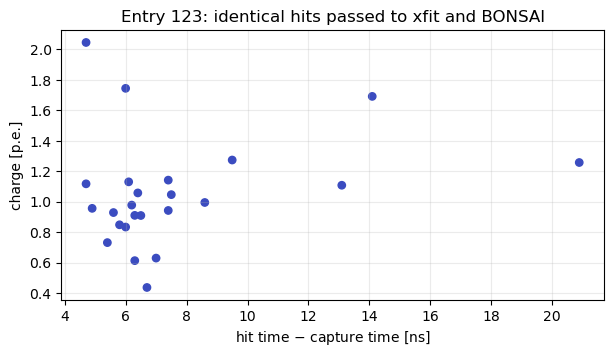

In [3]:
# Shared one-capture input used by both extraction xfit and BONSAI.
candidate = capture_candidate(
    entry=ONE_CAPTURE_ENTRY,
    time_window_ns=CAPTURE_TIME_WINDOW_NS,
)
truth_xyz = candidate["truth_xyz_cm"]
print("truth vertex [cm]:", truth_xyz)
print("input hits:", len(candidate["cable_ids"]))
print("truth capture hits:", candidate["n_true_capture_hits"])
print("capture purity:", candidate["capture_hit_fraction"])

# Quick look at the raw hit cluster selected around the truth capture time.
dt = candidate["times_raw_ns"] - candidate["capture_time_ns"]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.scatter(dt, candidate["charges_pe"], c=candidate["capture_flags"], cmap="coolwarm", s=28)
ax.set(
    xlabel=r"hit time $-$ capture time [ns]",
    ylabel="charge [p.e.]",
    title=f"Entry {ONE_CAPTURE_ENTRY}: identical hits passed to xfit and BONSAI",
)
ax.grid(alpha=0.25)

In [4]:
# Extraction xfit grid multilateration: one-capture check.
one_xfit = fit_extraction_xfit_candidate(candidate)
if not one_xfit["success"]:
    raise RuntimeError(f"extraction xfit failed: {one_xfit['failure_reason']}")
print(
    "extraction xfit seed/context/final hits:",
    one_xfit["n_seed_hits"],
    "->",
    one_xfit["n_context_hits"],
    "->",
    one_xfit["n_final_hits"],
)

grid_reco = np.asarray(one_xfit["vertex_cm"], dtype=float)
show_one_capture_check(
    "Extraction xfit grid multilateration",
    truth_xyz,
    grid_reco,
    {
        "Nn_seed_hits_for_fit": one_xfit["Nn"],
        "Nn_refit": one_xfit["Nn_refit"],
        "delta_Nn": one_xfit["delta_Nn"],
        "seed_trms_ns": one_xfit["seed_trms_ns"],
        "trms_refit_ns": one_xfit["trms_refit_ns"],
        "fpdist_cm": one_xfit["fpdist_cm"],
        "fwall_cm": one_xfit["fwall_cm"],
        "runtime_ms": one_xfit["runtime_ms"],
    },
)


extraction xfit seed/context/final hits: 23 -> 24 -> 23


,coordinate,truth_cm,reco_cm,reco_minus_truth_cm
0,x,15.105608,10.0,-5.105608
1,y,37.740715,20.5,-17.240715
2,z,3.859826,6.0,2.140174


Extraction xfit grid multilateration 3D residual: 18.11 cm


,value
Nn_seed_hits_for_fit,23.000000
Nn_refit,23.000000
delta_Nn,0.000000
seed_trms_ns,2.218092
trms_refit_ns,2.248157
fpdist_cm,15.362291
fwall_cm,118.348550
runtime_ms,77.436054


,value
fits,885.000000
median_cm,34.181600
mean_cm,44.265284
p68_cm,50.472277
p90_cm,90.163383
max_cm,181.715667


median |time residual|: 0.729 ns
68% |time residual|: 1.177 ns


,entry,event_number,capture_index,n_input_hits,n_mapped_hits,n_context_hits,n_seed_hits,n_final_hits,n_true_capture_hits,capture_hit_fraction,...,dt_ns,Nn,Nn_refit,delta_Nn,trms_ns,seed_trms_ns,fpdist_cm,fwall_cm,runtime_ms,algorithm
0,78,78,0,6,6,6,6,6,6,1.0,...,-1.463284,6,6,0,0.405694,0.852381,101.039596,10.34855,22.106966,extraction xfit grid
1,93,93,0,19,19,19,16,16,19,1.0,...,0.296554,16,16,0,1.082254,0.543247,33.166248,78.34855,52.849576,extraction xfit grid
2,108,108,0,24,24,24,21,21,24,1.0,...,0.727941,21,21,0,1.235432,1.372454,34.190642,118.34855,67.176997,extraction xfit grid
3,113,113,0,8,8,8,8,8,8,1.0,...,0.158598,8,8,0,0.410123,0.568870,27.586228,99.34855,41.119804,extraction xfit grid
4,123,123,0,24,24,24,23,23,24,1.0,...,0.229204,23,23,0,2.248157,2.218092,15.362291,118.34855,72.473816,extraction xfit grid
5,130,130,0,20,20,20,18,18,20,1.0,...,1.145659,18,18,0,0.798380,1.081378,39.458839,86.34855,58.458186,extraction xfit grid
6,188,188,0,43,43,43,41,41,43,1.0,...,0.429601,41,41,0,1.344789,1.425502,27.586228,89.34855,136.856675,extraction xfit grid
7,247,247,0,30,30,30,25,25,30,1.0,...,-0.312240,25,25,0,0.806288,0.901233,21.189620,88.34855,81.601808,extraction xfit grid
8,250,250,0,25,25,25,22,23,25,1.0,...,2.144926,22,23,1,2.262599,1.641533,52.057660,89.34855,71.746319,extraction xfit grid
9,275,275,0,14,14,14,12,12,14,1.0,...,-0.079674,12,12,0,0.957605,0.629233,36.837481,78.34855,43.332697,extraction xfit grid


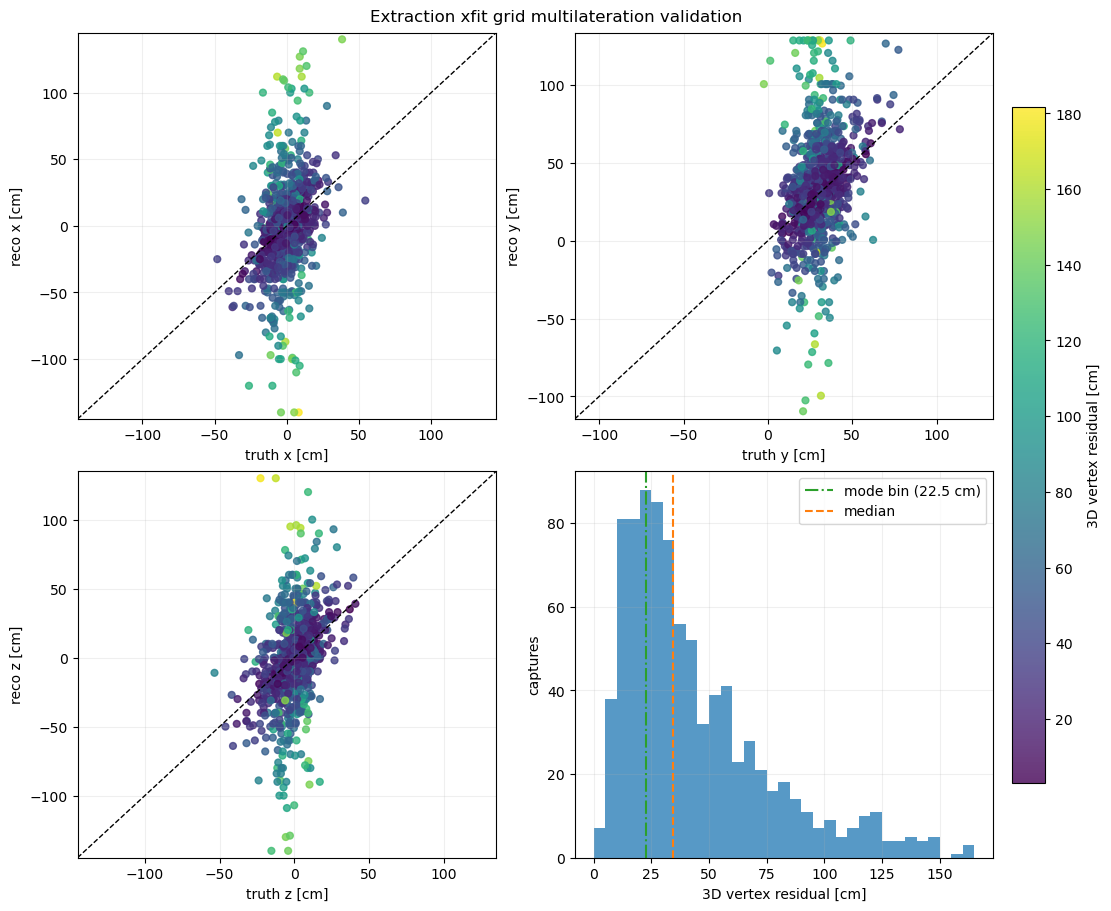

In [5]:
# Extraction xfit grid multilateration: validation-sample check.
grid_results = fit_extraction_xfit_candidates(
    validation_candidates(**VALIDATION_INPUT_KWARGS),
    max_fits=VALIDATION_MAX_FITS,
)
show_validation_checks(grid_results, "Extraction xfit grid multilateration validation")
grid_results.to_csv(XFIT_RESULTS_CSV, index=False)


In [6]:
# BONSAI setup from the same extraction adapter used in candidate_preselection.py.
if "bonsai_fitter" not in globals():
    bonsai_fitter = BonsaiVertexFitter(
        bonsai_dir=BONSAI_DIR,
        wcsim_dir=WCSIM_DIR,
        fit_param=FIT_PARAM,
        geometry_root=GEOMETRY_ROOT,
    )
bonsai_geometry_check = bonsai_fitter.validate_geometry(EXTRACTION_GEOMETRY)
display(pd.Series(bonsai_fitter.summary(), name="value").to_frame())
display(pd.Series(bonsai_geometry_check, name="value").to_frame())


,value
bonsai_dir,/scratch/saborido/WCTE/hk-BONSAI
wcsim_dir,/scratch/saborido/wcsim-dev/wcsim-install
fit_param,/scratch/saborido/WCTE/hk-BONSAI/data/fit_para...
geometry_root,/scratch/saborido/WCTE/hk-BONSAI/NiCf/wcsim_du...
n_pmts,1843


,value
n_pmts,1843.000000
max_position_difference_cm,0.000009


notNuPrism = 0
 Geometry Loading (NPMT=1843) 
Loaded 1843 PMT locations, maximum r=157.713089, maximum z=138.848557
reading /scratch/saborido/WCTE/hk-BONSAI/data/fit_param_wcte.dat...
BONSAI and Clusfit Shared Parameters
-------------------------------------------------------
PMT time resolution:                           1.00 ns
PMT coincidence time difference:               1.00 ns
PMT pair maximal distance fraction:            0.1785
PMT pair maximal time difference fraction:     0.1079
Maximum # of hits to do all 4-hit combin.:    20
Initial grid constant:                        50.00 cm
Minimum wall distance for 4-hit vertices:     50.00 cm

Clusfit Parameters
-------------------------------------------------------
Clusfit grid constant:                        50.00 cm
Minimum wall distance for Clusfit vertex:     10.00 cm
Initial Clusfit Cherenkov cone opening angle:  0.00 deg
Initial Clusfit angle positive deviation:   none
Initial Clusfit angle negative deviation:   none
Initia

In [7]:
# BONSAI: one-capture check through extraction.bonsai.BonsaiVertexFitter.
one_bonsai = fit_extraction_bonsai_candidate(bonsai_fitter, candidate)
if not one_bonsai["success"]:
    raise RuntimeError(f"BONSAI failed: {one_bonsai['failure_reason']}")
bonsai_reco = np.array([
    one_bonsai["reco_x_cm"],
    one_bonsai["reco_y_cm"],
    one_bonsai["reco_z_cm"],
], dtype=float)
show_one_capture_check(
    "BONSAI",
    truth_xyz,
    bonsai_reco,
    {
        "n_fit": one_bonsai["n_fit"],
        "n_selected_causal": one_bonsai["n_selected"],
        "n_selected_tof_window": one_bonsai["n_tof_window"],
        "time_goodness": one_bonsai["time_goodness"],
        "fit_goodness": one_bonsai["fit_goodness"],
        "runtime_ms": one_bonsai["runtime_ms"],
    },
)


,coordinate,truth_cm,reco_cm,reco_minus_truth_cm
0,x,15.105608,17.176218,2.070610
1,y,37.740715,32.013969,-5.726746
2,z,3.859826,-3.410341,-7.270167


BONSAI 3D residual: 9.48 cm


,value
n_fit,1320.000000
n_selected_causal,20.000000
n_selected_tof_window,23.000000
time_goodness,0.891206
fit_goodness,0.882543
runtime_ms,21.344875


,value
fits,848.000000
median_cm,21.815954
mean_cm,28.731095
p68_cm,30.331248
p90_cm,59.692140
max_cm,138.618268


time residuals: unavailable for this result table


,entry,event_number,capture_index,n_input_hits,n_selected,n_tof_window,n_true_capture_hits,capture_hit_fraction,truth_x_cm,truth_y_cm,...,residual_cm,capture_time_ns,reco_time_ns,dt_ns,time_goodness,fit_goodness,n_fit,runtime_ms,algorithm,failure_reason
0,78,78,0,6,6,6,6,1.0,-3.187194,30.393410,...,64.523898,119562.339432,NaN,NaN,0.993233,0.962905,133,0.897502,BONSAI,
1,93,93,0,19,16,17,19,1.0,-2.470124,25.946075,...,28.346631,29751.689817,NaN,NaN,0.845532,0.881534,945,9.162303,BONSAI,
2,108,108,0,24,18,22,24,1.0,-9.526496,36.001854,...,23.531640,74301.828824,NaN,NaN,0.852432,0.839750,1387,15.537674,BONSAI,
3,113,113,0,8,8,8,8,1.0,4.332549,16.057566,...,55.098447,221616.391693,NaN,NaN,0.992545,0.956530,248,1.573329,BONSAI,
4,123,123,0,24,20,23,24,1.0,15.105608,37.740715,...,9.483584,8098.736084,NaN,NaN,0.891206,0.882543,1320,15.406833,BONSAI,
5,130,130,0,20,17,20,20,1.0,1.577594,27.965483,...,41.398024,219389.418993,NaN,NaN,0.899298,0.888311,1173,11.666076,BONSAI,
6,169,169,0,7,7,4,7,1.0,0.842835,16.911556,...,39.039821,111113.884306,NaN,NaN,0.587601,0.751154,81,0.709830,BONSAI,
7,188,188,0,43,38,42,43,1.0,2.345587,23.585426,...,32.484151,248864.403445,NaN,NaN,0.931172,0.901268,1890,27.761981,BONSAI,
8,247,247,0,30,21,26,30,1.0,-5.551396,34.986408,...,16.914855,51181.513458,NaN,NaN,0.834933,0.847666,1260,16.866190,BONSAI,
9,250,250,0,25,14,24,25,1.0,12.394358,30.934469,...,27.487895,266519.704310,NaN,NaN,0.867619,0.830166,454,5.300908,BONSAI,


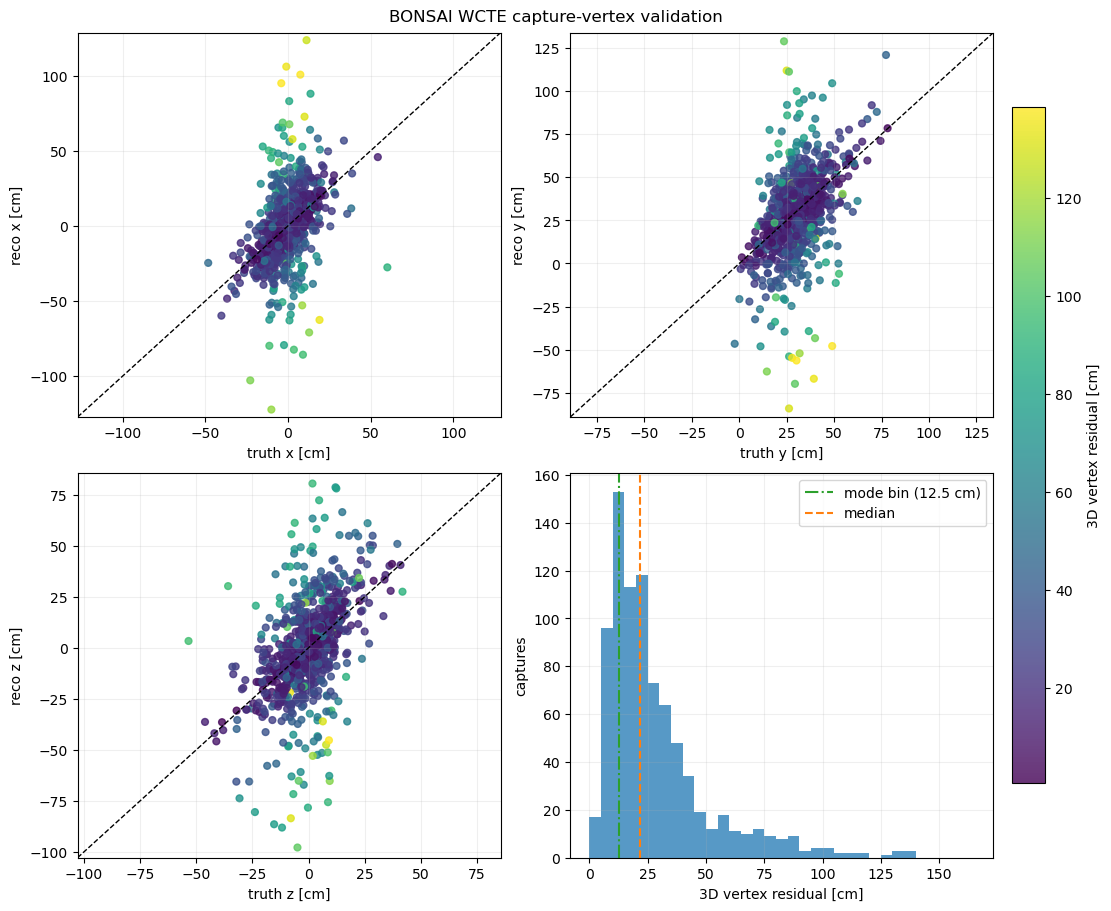

In [8]:
# BONSAI: validation-sample check through extraction.bonsai.BonsaiVertexFitter.
bonsai_results = fit_extraction_bonsai_candidates(
    bonsai_fitter,
    validation_candidates(**VALIDATION_INPUT_KWARGS),
    max_fits=VALIDATION_MAX_FITS,
)
show_validation_checks(bonsai_results, "BONSAI WCTE capture-vertex validation")
bonsai_results.to_csv(BONSAI_RESULTS_CSV, index=False)


In [9]:
# Cross-algorithm comparison tables.
def algorithm_summary(frame):
    """Return common summary metrics for any algorithm result table."""
    dt_abs = frame["dt_ns"].abs().dropna() if "dt_ns" in frame else pd.Series(dtype=float)
    return pd.Series({
        "fits": len(frame),
        "median residual [cm]": frame.residual_cm.median(),
        "68% residual [cm]": frame.residual_cm.quantile(0.68),
        "90% residual [cm]": frame.residual_cm.quantile(0.90),
        "median |dt| [ns]": dt_abs.median() if len(dt_abs) else np.nan,
        "68% |dt| [ns]": dt_abs.quantile(0.68) if len(dt_abs) else np.nan,
        "median runtime [ms]": frame.runtime_ms.median(),
    })

comparison_summary = pd.concat(
    {
        "extraction xfit grid": algorithm_summary(grid_results),
        "BONSAI": algorithm_summary(bonsai_results),
    },
    axis=1,
).T
display(comparison_summary)

comparison_results = pd.concat(
    [grid_results, bonsai_results],
    ignore_index=True,
    sort=False,
)
comparison_results.to_csv(COMPARISON_RESULTS_CSV, index=False)

,fits,median residual [cm],68% residual [cm],90% residual [cm],median |dt| [ns],68% |dt| [ns],median runtime [ms]
extraction xfit grid,885.0,34.181600,50.472277,90.163383,0.728626,1.177117,53.603453
BONSAI,848.0,21.815954,30.331248,59.692140,NaN,NaN,7.063478


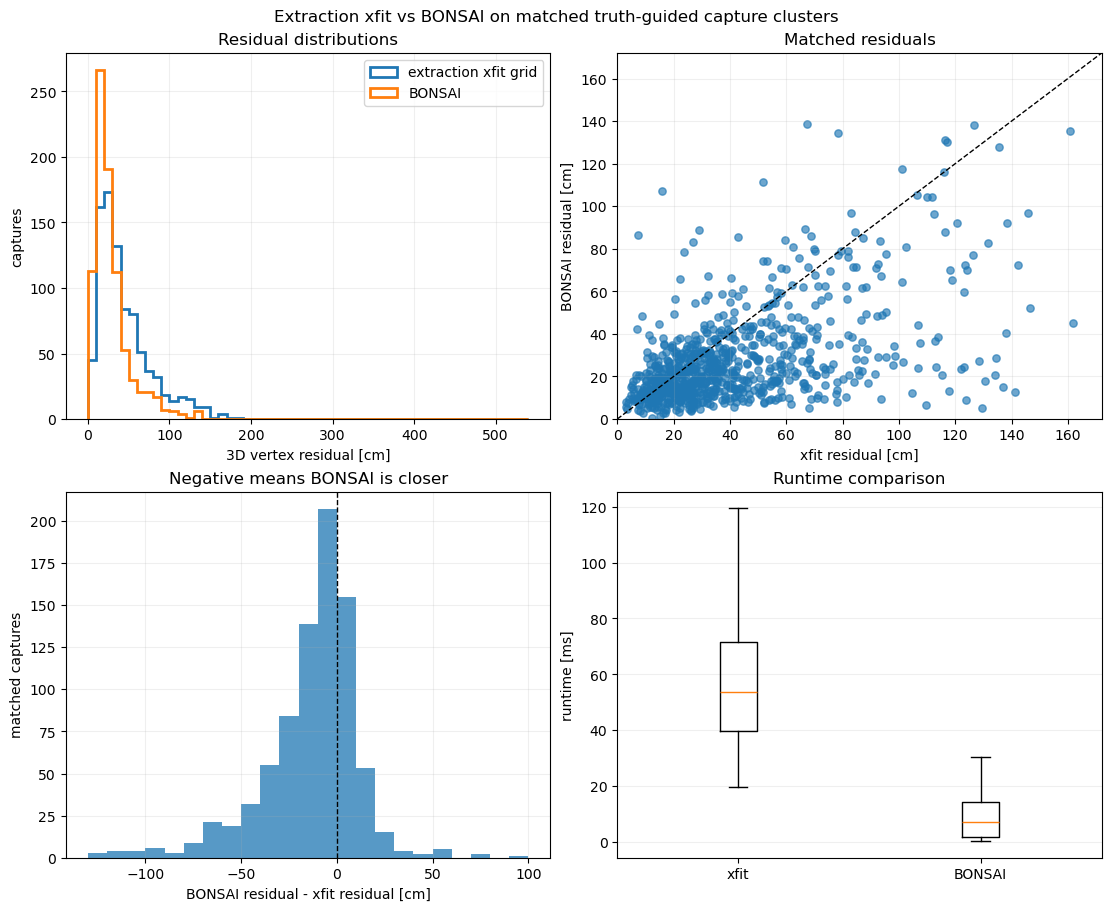

In [10]:
# Cross-algorithm comparison plots for extraction xfit and BONSAI.
matched = (
    grid_results[["entry", "capture_index", "residual_cm", "trms_ns", "fpdist_cm", "fwall_cm", "runtime_ms"]]
    .rename(columns={
        "residual_cm": "residual_cm_grid",
        "trms_ns": "trms_ns_grid",
        "runtime_ms": "runtime_ms_grid",
    })
    .merge(
        bonsai_results[["entry", "capture_index", "residual_cm", "runtime_ms"]].rename(columns={
            "residual_cm": "residual_cm_bonsai",
            "runtime_ms": "runtime_ms_bonsai",
        }),
        on=["entry", "capture_index"],
    )
)
matched["bonsai_minus_xfit_cm"] = matched.residual_cm_bonsai - matched.residual_cm_grid

fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
bins = np.arange(0, max(550, comparison_results.residual_cm.max() + 10), 10)
axes[0, 0].hist(grid_results.residual_cm, bins=bins, histtype="step", lw=2, label="extraction xfit grid")
axes[0, 0].hist(bonsai_results.residual_cm, bins=bins, histtype="step", lw=2, label="BONSAI")
axes[0, 0].set(xlabel="3D vertex residual [cm]", ylabel="captures", title="Residual distributions")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.2)

axes[0, 1].scatter(matched.residual_cm_grid, matched.residual_cm_bonsai, s=28, alpha=0.65)
lim = max(matched.residual_cm_grid.max(), matched.residual_cm_bonsai.max()) + 10
axes[0, 1].plot([0, lim], [0, lim], "k--", lw=1)
axes[0, 1].set(
    xlabel="xfit residual [cm]",
    ylabel="BONSAI residual [cm]",
    xlim=(0, lim),
    ylim=(0, lim),
    title="Matched residuals",
)
axes[0, 1].grid(alpha=0.2)

bins_delta = np.arange(
    np.floor(matched.bonsai_minus_xfit_cm.min() / 10) * 10,
    np.ceil(matched.bonsai_minus_xfit_cm.max() / 10) * 10 + 10,
    10,
)
axes[1, 0].hist(matched.bonsai_minus_xfit_cm, bins=bins_delta, histtype="stepfilled", alpha=0.75)
axes[1, 0].axvline(0, color="k", ls="--", lw=1)
axes[1, 0].set(
    xlabel="BONSAI residual - xfit residual [cm]",
    ylabel="matched captures",
    title="Negative means BONSAI is closer",
)
axes[1, 0].grid(alpha=0.2)

axes[1, 1].boxplot(
    [grid_results.runtime_ms.dropna(), bonsai_results.runtime_ms.dropna()],
    labels=["xfit", "BONSAI"],
    showfliers=False,
)
axes[1, 1].set(ylabel="runtime [ms]", title="Runtime comparison")
axes[1, 1].grid(alpha=0.2, axis="y")

fig.suptitle("Extraction xfit vs BONSAI on matched truth-guided capture clusters")
plt.show()